# Chapter 14. Quantum GAN

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- 양자 generator + 고전 discriminator의 하이브리드 GAN 구현
- 1차원 분포를 학습하는 미니 QGAN 만들기
- 학습 과정에서 분포가 어떻게 수렴하는지 시각화

In [6]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 14.1 학습 목표 분포
1차원 가우시안에서 샘플링한 데이터의 통계를 학습한다.
여기서는 단순하게 평균과 분산만 매칭하는 미니 QGAN을 만든다.

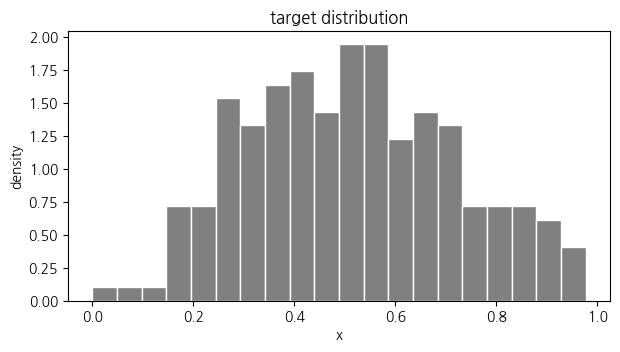

target 평균: 0.514, 표준편차: 0.204


In [7]:
rng = np.random.RandomState(0)
target_data = rng.normal(0.5, 0.2, 200)
target_data = np.clip(target_data, 0, 1)

plt.figure(figsize=(7, 3.5))
plt.hist(target_data, bins=20, color='gray', edgecolor='white', density=True)
plt.title('target distribution')
plt.xlabel('x'); plt.ylabel('density')
plt.show()
print(f'target 평균: {target_data.mean():.3f}, 표준편차: {target_data.std():.3f}')

## 14.2 양자 Generator
단일 큐비트 회로의 측정 확률 P(0)를 생성된 sample로 사용한다.
노이즈 z는 입력 회전 각도로 들어간다.

In [8]:
dev_g = qml.device('default.qubit', wires=1)

@qml.qnode(dev_g, interface='autograd')
def generator_circuit(z, params):
    # 노이즈 인코딩
    qml.RY(z, wires=0)
    # 변분 회전들
    qml.Rot(params[0], params[1], params[2], wires=0)
    qml.RX(params[3], wires=0)
    qml.RY(params[4], wires=0)
    # 출력: <Z> 측정 (0 ~ 1 범위로 변환 가능)
    return qml.expval(qml.PauliZ(0))

def generator(z, params):
    # <Z> ∈ [-1, 1] 을 [0, 1]로 매핑
    return (1 - generator_circuit(z, params)) / 2

def generate(params, n_samples=100):
    z = rng.uniform(0, 2 * np.pi, n_samples)
    return np.array([generator(zi, params) for zi in z])

## 14.3 간단한 통계 매칭 학습
본격적인 minimax 대신, 평균/분산을 매칭하는 손실로 학습한다 (학습 안정성 ↑).

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

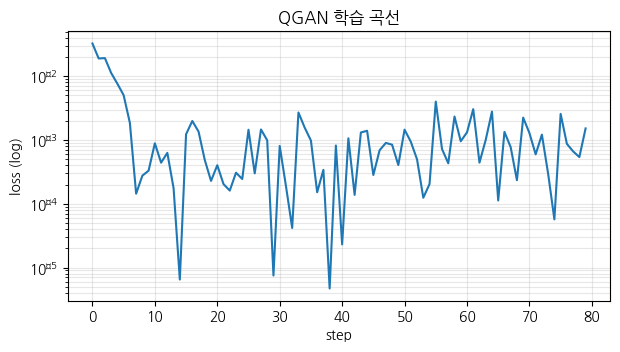

In [9]:
def loss(params):
    z = pnp.array(rng.uniform(0, 2 * np.pi, 60), requires_grad=False)
    fake = pnp.stack([generator(zi, params) for zi in z])
    # 평균과 분산을 동시에 매칭
    mean_loss = (pnp.mean(fake) - target_data.mean()) ** 2
    var_loss = (pnp.var(fake) - target_data.var()) ** 2
    return mean_loss + 5.0 * var_loss

params = pnp.array(rng.uniform(0, 2 * np.pi, 5), requires_grad=True)
opt = qml.AdamOptimizer(0.05)

history = []
snapshots = {}
for step in range(80):
    params, c = opt.step_and_cost(loss, params)
    history.append(float(c))
    if step in [0, 25, 50, 79]:
        snapshots[step] = generate(params, 200)

plt.figure(figsize=(7, 3.5))
plt.semilogy(history)
plt.xlabel('step'); plt.ylabel('loss (log)')
plt.title('QGAN 학습 곡선')
plt.grid(alpha=0.3, which='both')
plt.show()

## 14.4 생성된 분포의 변화

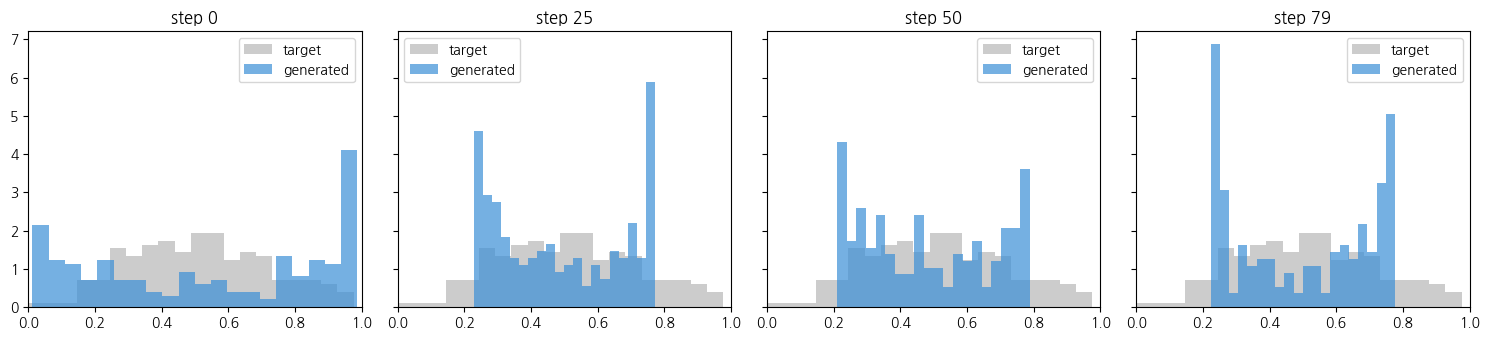

최종 생성 평균: 0.499  (target: 0.514)
최종 생성 표준편차: 0.188  (target: 0.204)


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, (step, fake) in zip(axes, snapshots.items()):
    ax.hist(target_data, bins=20, color='gray', alpha=0.4, density=True, label='target')
    ax.hist(fake, bins=20, color='#3b8fd6', alpha=0.7, density=True, label='generated')
    ax.set_title(f'step {step}')
    ax.set_xlim(0, 1)
    ax.legend()
plt.tight_layout()
plt.show()

final = generate(params, 500)
print(f'최종 생성 평균: {final.mean():.3f}  (target: {target_data.mean():.3f})')
print(f'최종 생성 표준편차: {final.std():.3f}  (target: {target_data.std():.3f})')

## 14.5 정리
- QGAN은 양자 generator + 고전 discriminator의 minimax 게임으로 정의된다.
- 여기서는 학습 안정성을 위해 통계 매칭 손실로 단순화했다.
- 풀 minimax QGAN은 학습 동역학이 까다롭지만 분포 학습에 강력하다.